In [5]:
import zipfile

with zipfile.ZipFile("archive (4).zip", 'r') as zip_ref:
    zip_ref.extractall()

print("ZIP Extracted Successfully")

ZIP Extracted Successfully


In [6]:
import os
print(os.listdir())

['.config', 'archive (4).zip', 'heart-disease-predictions (1).ipynb', 'heart-disease.csv', 'heart-disease-predictions.ipynb', 'sample_data']


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

LOGISTIC REGRESSION ACCURACY: 0.8524590163934426

SVM ACCURACY: 0.8688524590163934

RANDOM FOREST ACCURACY: 0.8360655737704918

XGBOOST ACCURACY: 0.819672131147541

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy               

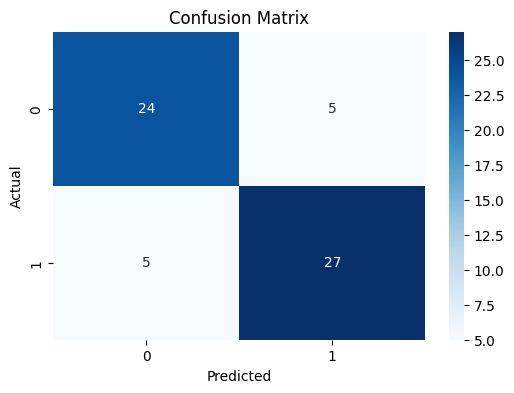

In [7]:
!pip install xgboost -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Load Dataset
data = pd.read_csv("heart-disease.csv")

print(data.head())

# Features & Target
X = data.drop('target', axis=1)
y = data['target']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# SVM
svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# XGBoost
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

# Results
print("\nLOGISTIC REGRESSION ACCURACY:",
      accuracy_score(y_test, lr_pred))

print("\nSVM ACCURACY:",
      accuracy_score(y_test, svm_pred))

print("\nRANDOM FOREST ACCURACY:",
      accuracy_score(y_test, rf_pred))

print("\nXGBOOST ACCURACY:",
      accuracy_score(y_test, xgb_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()